In [ ]:
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# Define the QNN using the Estimator Primitive
qnn = EstimatorQNN(circuit=your_circuit, input_params=inputs, weight_params=weights)

# Connect it to PyTorch
quantum_layer = TorchConnector(qnn)

In [ ]:
import torch.nn as nn

class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.clayer1 = nn.Linear(10, 4) # Classical pre-processing
        self.qlayer  = quantum_layer    # The Quantum Layer
        self.clayer2 = nn.Linear(1, 1)  # Classical post-processing

    def forward(self, x):
        x = self.clayer1(x)
        x = self.qlayer(x)
        x = self.clayer2(x)
        return x

In [75]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes, PauliTwoDesign
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit.primitives import StatevectorEstimator as Estimator

# 1. Data Preparation (Iris Dataset - 2 classes for simplicity)
iris = load_iris()
X = iris.data[iris.target < 2]  # Use only 2 classes for binary classification
y = iris.target[iris.target < 2]

# Scale features to match the number of qubits (Padding 4 features to 5)
scaler = MinMaxScaler(feature_range=(0, 3.14))
X_scaled = scaler.fit_transform(X)
X_padded = torch.cat([torch.tensor(X_scaled), torch.zeros((len(X_scaled), 1))], dim=1).float()
y_tensor = torch.tensor(y).float().unsqueeze(1)

X_train, X_test, y_train, y_test = train_test_split(X_padded, y_tensor, test_size=0.2)

# 2. Define the Quantum Circuit (5 Qubits)
num_qubits = 5
# Define the observable: Measure Z on all 5 qubits
# "Z" * num_qubits creates the string "ZZZZZ"
observable = SparsePauliOp("Z" * 5)
# Feature map to encode classical data
feature_map = ZZFeatureMap(num_qubits, reps=1)
# Ansatz with two local blocks (reps=2) for parameter training
# ansatz = RealAmplitudes(num_qubits, reps=2)
ansatz = PauliTwoDesign(num_qubits, reps=2)

qc = QuantumCircuit(num_qubits)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

# 3. Create the Quantum Neural Network (QNN)
qnn = EstimatorQNN(
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    observables=observable,
    estimator=Estimator(),
    input_gradients=True
)

# 4. Define the Hybrid Model
class HybridNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Classical pre-processing
        self.fc1 = nn.Linear(5, 5)
        # Quantum Layer
        self.q_layer = TorchConnector(qnn)
        # Classical post-processing (maps parity/expectation to class)
        self.fc2 = nn.Linear(1, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.q_layer(x)
        x = self.fc2(x)
        return self.sigmoid(x)

model = HybridNet()
optimizer = optim.Adam(model.parameters(), lr=0.05)
loss_fn = nn.BCELoss()

# 5. Training Loop
print("Starting Hybrid Training...")
for epoch in range(20):
    print(f"Epoch {epoch+1}/20")
    optimizer.zero_grad()
    output = model(X_train)
    loss = loss_fn(output, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 5 == 0:
        print(f"Epoch {epoch} - Loss: {loss.item():.4f}")

# 6. Evaluation
model.eval()
with torch.no_grad():
    test_out = model(X_test)
    predictions = (test_out > 0.5).float()
    accuracy = (predictions == y_test).float().mean()
    print(f"\nFinal Test Accuracy: {accuracy.item() * 100:.2f}%")

/var/folders/pw/32nbfc552rjgfjxrmmf417g00000gn/T/ipykernel_6561/3266512698.py:34: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(num_qubits, reps=1)
/var/folders/pw/32nbfc552rjgfjxrmmf417g00000gn/T/ipykernel_6561/3266512698.py:37: DeprecationWarning: The class ``qiskit.circuit.library.n_local.pauli_two_design.PauliTwoDesign`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.pauli_two_design instead.
  ansatz = PauliTwoDesign(num_qubits, reps=2)
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Starting Hybrid Training...
Epoch 1/20
Epoch 0 - Loss: 0.7788
Epoch 2/20
Epoch 3/20
Epoch 4/20
Epoch 5/20
Epoch 6/20
Epoch 5 - Loss: 0.7294
Epoch 7/20
Epoch 8/20
Epoch 9/20
Epoch 10/20
Epoch 11/20
Epoch 10 - Loss: 0.6980
Epoch 12/20
Epoch 13/20
Epoch 14/20
Epoch 15/20
Epoch 16/20
Epoch 15 - Loss: 0.6405
Epoch 17/20
Epoch 18/20
Epoch 19/20
Epoch 20/20

Final Test Accuracy: 80.00%


# Comparison with a Pure classical model

In [74]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit.primitives import StatevectorEstimator as Estimator

import datetime

# 1. Data Preparation (Iris Dataset - 2 classes for simplicity)
iris = load_iris()
X = iris.data[iris.target < 2]  # Use only 2 classes for binary classification
y = iris.target[iris.target < 2]

# Scale features to match the number of qubits (Padding 4 features to 5)
scaler = MinMaxScaler(feature_range=(0, 3.14))
X_scaled = scaler.fit_transform(X)
X_padded = torch.cat([torch.tensor(X_scaled), torch.zeros((len(X_scaled), 1))], dim=1).float()
y_tensor = torch.tensor(y).float().unsqueeze(1)

X_train, X_test, y_train, y_test = train_test_split(X_padded, y_tensor, test_size=0.2)

# 2. Define the Quantum Circuit (5 Qubits)
num_qubits = 5
# Define the observable: Measure Z on all 5 qubits
# "Z" * num_qubits creates the string "ZZZZZ"
# observable = SparsePauliOp("Z" * 5)
# # Feature map to encode classical data
# feature_map = ZZFeatureMap(num_qubits, reps=1)
# # Ansatz with two local blocks (reps=2) for parameter training
# ansatz = RealAmplitudes(num_qubits, reps=2)

# qc = QuantumCircuit(num_qubits)
# qc.compose(feature_map, inplace=True)
# qc.compose(ansatz, inplace=True)

# # 3. Create the Quantum Neural Network (QNN)
# qnn = EstimatorQNN(
#     circuit=qc,
#     input_params=feature_map.parameters,
#     weight_params=ansatz.parameters,
#     observables=observable,
#     estimator=Estimator(),
#     input_gradients=True
# )

# 4. Define the Hybrid Model
class HybridNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Classical pre-processing
        self.fc1 = nn.Linear(5, 5)
        # Quantum Layer
        # self.q_layer = TorchConnector(qnn)
        self.q_layer = nn.Linear(5, 1)
        # Classical post-processing (maps parity/expectation to class)
        self.fc2 = nn.Linear(1, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.q_layer(x)
        x = self.fc2(x)
        return self.sigmoid(x)

model = HybridNet()
optimizer = optim.Adam(model.parameters(), lr=0.05)
loss_fn = nn.BCELoss()

# 5. Training Loop
print("Starting Classical Training...")
print(f"{datetime.datetime.now()}")
for epoch in range(20):
    print(f"Epoch {epoch+1}/20")
    optimizer.zero_grad()
    output = model(X_train)
    loss = loss_fn(output, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 5 == 0:
        print(f"Epoch {epoch} - Loss: {loss.item():.4f}")

# 6. Evaluation
model.eval()
with torch.no_grad():
    test_out = model(X_test)
    predictions = (test_out > 0.5).float()
    accuracy = (predictions == y_test).float().mean()
    print(f"\nFinal Test Accuracy: {accuracy.item() * 100:.2f}%")
print(f"{datetime.datetime.now()}")


Starting Classical Training...
2026-05-13 10:19:23.089121
Epoch 1/20
Epoch 0 - Loss: 0.7258
Epoch 2/20
Epoch 3/20
Epoch 4/20
Epoch 5/20
Epoch 6/20
Epoch 5 - Loss: 0.5052
Epoch 7/20
Epoch 8/20
Epoch 9/20
Epoch 10/20
Epoch 11/20
Epoch 10 - Loss: 0.1323
Epoch 12/20
Epoch 13/20
Epoch 14/20
Epoch 15/20
Epoch 16/20
Epoch 15 - Loss: 0.0088
Epoch 17/20
Epoch 18/20
Epoch 19/20
Epoch 20/20

Final Test Accuracy: 100.00%
2026-05-13 10:19:23.103112


# Comparator

/var/folders/pw/32nbfc552rjgfjxrmmf417g00000gn/T/ipykernel_6561/1505192348.py:47: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(num_qubits, reps=1)
/var/folders/pw/32nbfc552rjgfjxrmmf417g00000gn/T/ipykernel_6561/1505192348.py:48: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits, reps=2)
/var/folders/pw/32nbfc552rjgfjxrmmf417g00000gn/T/ipykernel_6561/1505192348.py:49: DeprecationWarning: The class ``qiskit.circuit.library.n_local.pauli_two_design.PauliTwoDesign`` is deprecated as of Qiskit

Training Classical Model...
Training Hybrid Quantum Model... (This may take a minute)
Training Hybrid Quantum Model (Pauli)... (This may take a minute)


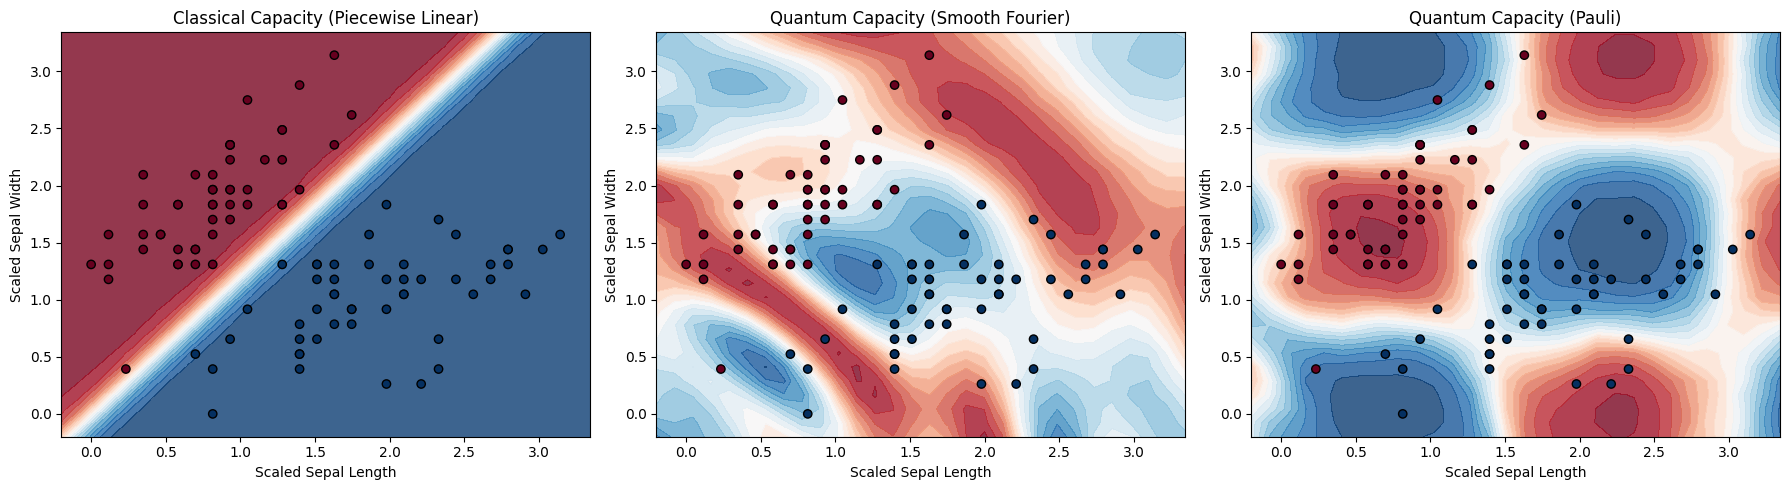

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# ==========================================
# 1. DATA PREPARATION (2D for Visualization)
# ==========================================
iris = load_iris()
# Use only 2 classes and the first 2 features (Sepal length & width)
X = iris.data[iris.target < 2, :2] 
y = iris.target[iris.target < 2]

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X)

X_tensor = torch.tensor(X_scaled).float()
y_tensor = torch.tensor(y).float().unsqueeze(1)

# ==========================================
# 2. DEFINE THE MODELS
# ==========================================
# A. Classical Model (Matching parameter complexity ~15 params)
class ClassicalNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# B. Hybrid Quantum Model
num_qubits = 2
feature_map = ZZFeatureMap(num_qubits, reps=1)
ansatz = RealAmplitudes(num_qubits, reps=2)
ansatz2 = PauliTwoDesign(num_qubits, reps=2)
qc = QuantumCircuit(num_qubits)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

qc2 = QuantumCircuit(num_qubits)
qc2.compose(feature_map, inplace=True)
qc2.compose(ansatz2, inplace=True)

observable = SparsePauliOp("Z" * num_qubits)
qnn = EstimatorQNN(
    circuit=qc,
    observables=observable,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=Estimator(),
    input_gradients=True
)

qnn2 = EstimatorQNN(
    circuit=qc2,
    observables=observable,
    input_params=feature_map.parameters,
    weight_params=ansatz2.parameters,
    estimator=Estimator(),
    input_gradients=True
)

class HybridNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.q_layer = TorchConnector(qnn)
        self.fc = nn.Linear(1, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.q_layer(x)
        return self.sigmoid(self.fc(x))
    
class HybridNetPauli(nn.Module):
    def __init__(self):
        super().__init__()
        self.q_layer = TorchConnector(qnn2)
        self.fc = nn.Linear(1, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.q_layer(x)
        return self.sigmoid(self.fc(x))

model_c = ClassicalNet()
model_q = HybridNet()
model_q_pauli = HybridNetPauli()

# ==========================================
# 3. TRAINING LOOP
# ==========================================
def train_model(model, epochs=40, lr=0.1):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = loss_fn(model(X_tensor), y_tensor)
        loss.backward()
        optimizer.step()

print("Training Classical Model...")
train_model(model_c)

print("Training Hybrid Quantum Model... (This may take a minute)")
train_model(model_q)

print("Training Hybrid Quantum Model (Pauli)... (This may take a minute)")
train_model(model_q_pauli)

# ==========================================
# 4. VISUALIZING DECISION BOUNDARIES
# ==========================================
def plot_decision_boundary(model, title, ax):
    x_min, x_max = X_scaled[:, 0].min() - 0.2, X_scaled[:, 0].max() + 0.2
    y_min, y_max = X_scaled[:, 1].min() - 0.2, X_scaled[:, 1].max() + 0.2
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 30),
                         np.linspace(y_min, y_max, 30))
    
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()]).float()
    with torch.no_grad():
        Z = model(grid).numpy().reshape(xx.shape)
        
    contour = ax.contourf(xx, yy, Z, levels=20, cmap="RdBu", alpha=0.8)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap="RdBu", edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel("Scaled Sepal Length")
    ax.set_ylabel("Scaled Sepal Width")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
plot_decision_boundary(model_c, "Classical Capacity (Piecewise Linear)", ax1)
plot_decision_boundary(model_q, "Quantum Capacity (Smooth Fourier)", ax2)
plot_decision_boundary(model_q_pauli, "Quantum Capacity (Pauli)", ax3)
plt.tight_layout()
plt.show()

/var/folders/pw/32nbfc552rjgfjxrmmf417g00000gn/T/ipykernel_6561/1505192348.py:47: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(num_qubits, reps=1)
/var/folders/pw/32nbfc552rjgfjxrmmf417g00000gn/T/ipykernel_6561/1505192348.py:48: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits, reps=2)
/var/folders/pw/32nbfc552rjgfjxrmmf417g00000gn/T/ipykernel_6561/1505192348.py:49: DeprecationWarning: The class ``qiskit.circuit.library.n_local.pauli_two_design.PauliTwoDesign`` is deprecated as of Qiskit

Training Classical Model...
Training Hybrid Quantum Model... (This may take a minute)
Training Hybrid Quantum Model (Pauli)... (This may take a minute)


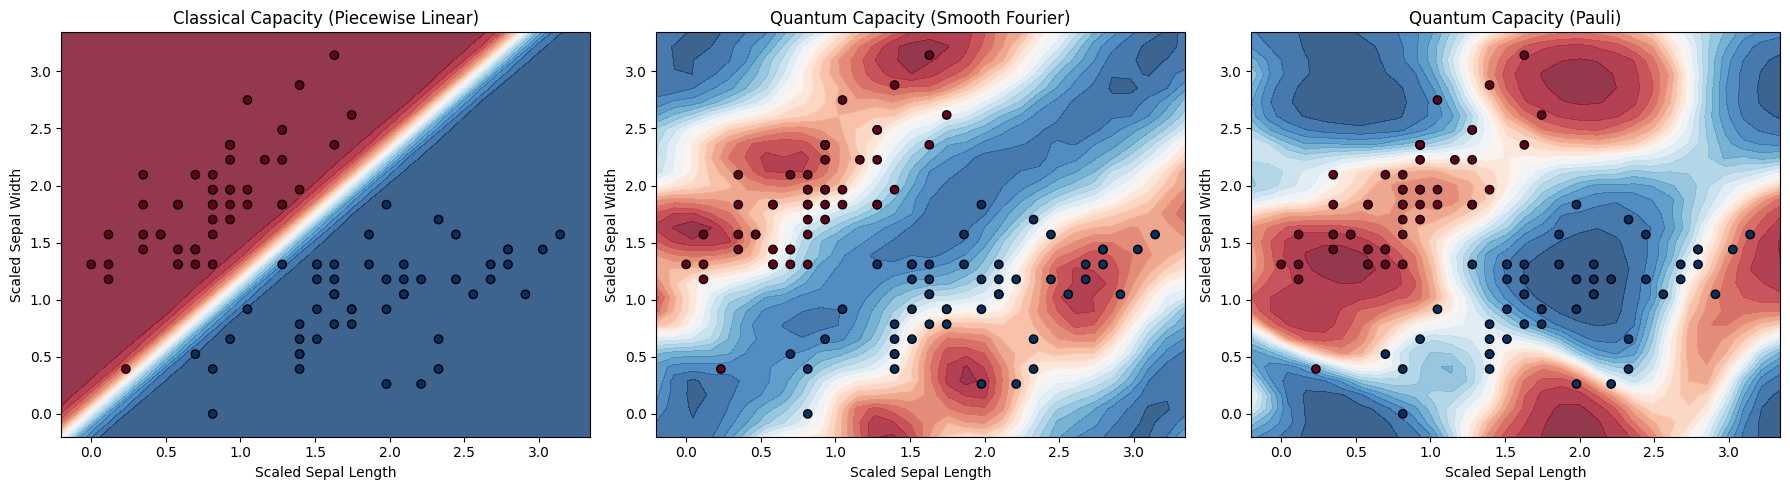

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# ==========================================
# 1. DATA PREPARATION (2D for Visualization)
# ==========================================
iris = load_iris()
# Use only 2 classes and the first 2 features (Sepal length & width)
X = iris.data[iris.target < 2, :2] 
y = iris.target[iris.target < 2]

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X)

X_tensor = torch.tensor(X_scaled).float()
y_tensor = torch.tensor(y).float().unsqueeze(1)

# ==========================================
# 2. DEFINE THE MODELS
# ==========================================
# A. Classical Model (Matching parameter complexity ~15 params)
class ClassicalNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# B. Hybrid Quantum Model
num_qubits = 2
feature_map = ZZFeatureMap(num_qubits, reps=1)
ansatz = RealAmplitudes(num_qubits, reps=2)
ansatz2 = PauliTwoDesign(num_qubits, reps=2)
qc = QuantumCircuit(num_qubits)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

qc2 = QuantumCircuit(num_qubits)
qc2.compose(feature_map, inplace=True)
qc2.compose(ansatz2, inplace=True)

observable = SparsePauliOp("Z" * num_qubits)
qnn = EstimatorQNN(
    circuit=qc,
    observables=observable,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=Estimator(),
    input_gradients=True
)

qnn2 = EstimatorQNN(
    circuit=qc2,
    observables=observable,
    input_params=feature_map.parameters,
    weight_params=ansatz2.parameters,
    estimator=Estimator(),
    input_gradients=True
)

class HybridNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.q_layer = TorchConnector(qnn)
        self.fc = nn.Linear(1, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.q_layer(x)
        return self.sigmoid(self.fc(x))
    
class HybridNetPauli(nn.Module):
    def __init__(self):
        super().__init__()
        self.q_layer = TorchConnector(qnn2)
        self.fc = nn.Linear(1, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.q_layer(x)
        return self.sigmoid(self.fc(x))

model_c = ClassicalNet()
model_q = HybridNet()
model_q_pauli = HybridNetPauli()

# ==========================================
# 3. TRAINING LOOP
# ==========================================
def train_model(model, epochs=40, lr=0.1):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = loss_fn(model(X_tensor), y_tensor)
        loss.backward()
        optimizer.step()

print("Training Classical Model...")
train_model(model_c)

print("Training Hybrid Quantum Model... (This may take a minute)")
train_model(model_q)

print("Training Hybrid Quantum Model (Pauli)... (This may take a minute)")
train_model(model_q_pauli)

# ==========================================
# 4. VISUALIZING DECISION BOUNDARIES
# ==========================================
def plot_decision_boundary(model, title, ax):
    x_min, x_max = X_scaled[:, 0].min() - 0.2, X_scaled[:, 0].max() + 0.2
    y_min, y_max = X_scaled[:, 1].min() - 0.2, X_scaled[:, 1].max() + 0.2
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 30),
                         np.linspace(y_min, y_max, 30))
    
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()]).float()
    with torch.no_grad():
        Z = model(grid).numpy().reshape(xx.shape)
        
    contour = ax.contourf(xx, yy, Z, levels=20, cmap="RdBu", alpha=0.8)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap="RdBu", edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel("Scaled Sepal Length")
    ax.set_ylabel("Scaled Sepal Width")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
plot_decision_boundary(model_c, "Classical Capacity (Piecewise Linear)", ax1)
plot_decision_boundary(model_q, "Quantum Capacity (Smooth Fourier)", ax2)
plot_decision_boundary(model_q_pauli, "Quantum Capacity (Pauli)", ax3)
plt.tight_layout()
plt.show()

/var/folders/pw/32nbfc552rjgfjxrmmf417g00000gn/T/ipykernel_6561/1856950990.py:47: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(num_qubits, reps=1)
/var/folders/pw/32nbfc552rjgfjxrmmf417g00000gn/T/ipykernel_6561/1856950990.py:48: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits, reps=2)
/var/folders/pw/32nbfc552rjgfjxrmmf417g00000gn/T/ipykernel_6561/1856950990.py:49: DeprecationWarning: The class ``qiskit.circuit.library.n_local.pauli_two_design.PauliTwoDesign`` is deprecated as of Qiskit

Training Classical Model...
Training Hybrid Quantum Model... (This may take a minute)
Training Hybrid Quantum Model (Pauli)... (This may take a minute)


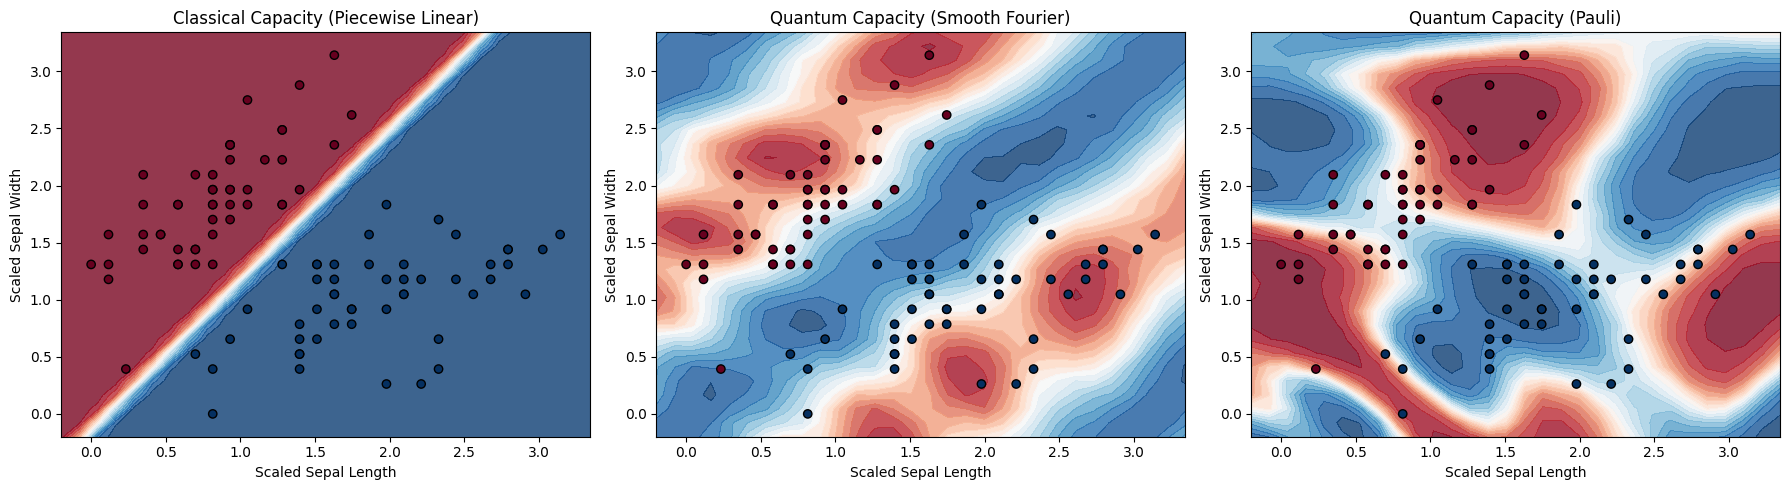

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# ==========================================
# 1. DATA PREPARATION (2D for Visualization)
# ==========================================
iris = load_iris()
# Use only 2 classes and the first 2 features (Sepal length & width)
X = iris.data[iris.target < 2, :2] 
y = iris.target[iris.target < 2]

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X)

X_tensor = torch.tensor(X_scaled).float()
y_tensor = torch.tensor(y).float().unsqueeze(1)

# ==========================================
# 2. DEFINE THE MODELS
# ==========================================
# A. Classical Model (Matching parameter complexity ~15 params)
class ClassicalNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# B. Hybrid Quantum Model
num_qubits = 2
feature_map = ZZFeatureMap(num_qubits, reps=1)
ansatz = RealAmplitudes(num_qubits, reps=2)
ansatz2 = PauliTwoDesign(num_qubits, reps=2)
qc = QuantumCircuit(num_qubits)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

qc2 = QuantumCircuit(num_qubits)
qc2.compose(feature_map, inplace=True)
qc2.compose(ansatz2, inplace=True)

observable = SparsePauliOp("Z" * num_qubits)
qnn = EstimatorQNN(
    circuit=qc,
    observables=observable,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=Estimator(),
    input_gradients=True
)

qnn2 = EstimatorQNN(
    circuit=qc2,
    observables=observable,
    input_params=feature_map.parameters,
    weight_params=ansatz2.parameters,
    estimator=Estimator(),
    input_gradients=True
)

class HybridNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.q_layer = TorchConnector(qnn)
        self.fc = nn.Linear(1, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.q_layer(x)
        return self.sigmoid(self.fc(x))
    
class HybridNetPauli(nn.Module):
    def __init__(self):
        super().__init__()
        self.q_layer = TorchConnector(qnn2)
        self.fc = nn.Linear(1, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.q_layer(x)
        return self.sigmoid(self.fc(x))

model_c = ClassicalNet()
model_q = HybridNet()
model_q_pauli = HybridNetPauli()

# ==========================================
# 3. TRAINING LOOP
# ==========================================
def train_model(model, epochs=300, lr=0.1):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = loss_fn(model(X_tensor), y_tensor)
        loss.backward()
        optimizer.step()

print("Training Classical Model...")
train_model(model_c)

print("Training Hybrid Quantum Model... (This may take a minute)")
train_model(model_q)

print("Training Hybrid Quantum Model (Pauli)... (This may take a minute)")
train_model(model_q_pauli)

# ==========================================
# 4. VISUALIZING DECISION BOUNDARIES
# ==========================================
def plot_decision_boundary(model, title, ax):
    x_min, x_max = X_scaled[:, 0].min() - 0.2, X_scaled[:, 0].max() + 0.2
    y_min, y_max = X_scaled[:, 1].min() - 0.2, X_scaled[:, 1].max() + 0.2
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 30),
                         np.linspace(y_min, y_max, 30))
    
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()]).float()
    with torch.no_grad():
        Z = model(grid).numpy().reshape(xx.shape)
        
    contour = ax.contourf(xx, yy, Z, levels=20, cmap="RdBu", alpha=0.8)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap="RdBu", edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel("Scaled Sepal Length")
    ax.set_ylabel("Scaled Sepal Width")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
plot_decision_boundary(model_c, "Classical Capacity (Piecewise Linear)", ax1)
plot_decision_boundary(model_q, "Quantum Capacity (Smooth Fourier)", ax2)
plot_decision_boundary(model_q_pauli, "Quantum Capacity (Pauli)", ax3)
plt.tight_layout()
plt.show()

In [ ]:
## MODEL EVOLUTION COMPARISON

total_epochs = 300
snapshot_interval = 3

model_snapshots = []

def plot_decision_boundary(model, title, ax):
    x_min, x_max = X_scaled[:, 0].min() - 0.2, X_scaled[:, 0].max() + 0.2
    y_min, y_max = X_scaled[:, 1].min() - 0.2, X_scaled[:, 1].max() + 0.2
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 30),
                         np.linspace(y_min, y_max, 30))
    
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()]).float()
    with torch.no_grad():
        Z = model(grid).numpy().reshape(xx.shape)
        
    contour = ax.contourf(xx, yy, Z, levels=20, cmap="RdBu", alpha=0.8)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap="RdBu", edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel("Scaled Sepal Length")
    ax.set_ylabel("Scaled Sepal Width")

def train_models(model1, model2, model3, epochs=30, lr=0.1, interval=5, model_snapshots=None):
    print("Starting model training with snapshots every", interval, "for ", epochs, "epochs...")
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()

    optimizer2 = optim.Adam(model.parameters(), lr=lr)
    loss_fn2 = nn.BCELoss()

    optimizer3 = optim.Adam(model.parameters(), lr=lr)
    loss_fn3 = nn.BCELoss()

    for epoch in range(epochs):
        print(f"Epoch {epoch}/{epochs}")
        optimizer.zero_grad()
        loss = loss_fn(model1(X_tensor), y_tensor)
        loss.backward()
        optimizer.step()

        optimizer2.zero_grad()
        loss2 = loss_fn2(model2(X_tensor), y_tensor)
        loss2.backward()
        optimizer2.step()

        optimizer3.zero_grad()
        loss3 = loss_fn3(model3(X_tensor), y_tensor)
        loss3.backward()
        optimizer3.step()

        if epoch % interval == 0:
            print(f"Epoch {epoch} - Loss: {loss.item():.4f}")
            if model_snapshots is not None:
                print("Capturing model snapshots...")
                fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
                plot_decision_boundary(model1, "Classical Capacity (Piecewise Linear)", ax1)
                plot_decision_boundary(model2, "Quantum Capacity (Smooth Fourier)", ax2)
                plot_decision_boundary(model3, "Quantum Capacity (Pauli)", ax3)
                model_snapshots.append(fig)

train_models(model_c, model_q, model_q_pauli, epochs=total_epochs, lr=0.1, interval=snapshot_interval, model_snapshots=model_snapshots)

# for epoch in range(total_epochs):

# print("Training Classical Model...")
# train_model(model_c)

# print("Training Hybrid Quantum Model... (This may take a minute)")
# train_model(model_q)

# print("Training Hybrid Quantum Model (Pauli)... (This may take a minute)")
# train_model(model_q_pauli)

# fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
# plot_decision_boundary(model_c, "Classical Capacity (Piecewise Linear)", ax1)
# plot_decision_boundary(model_q, "Quantum Capacity (Smooth Fourier)", ax2)
# plot_decision_boundary(model_q_pauli, "Quantum Capacity (Pauli)", ax3)
# plt.tight_layout()
# plt.show()

Starting model training with snapshots every 3 for  300 epochs...
Epoch 0/300
Epoch 0 - Loss: 0.0015
Capturing model snapshots...
Epoch 1/300
Epoch 2/300
Epoch 3/300
Epoch 3 - Loss: 0.0015
Capturing model snapshots...
Epoch 4/300
Epoch 5/300
Epoch 6/300
Epoch 6 - Loss: 0.0015
Capturing model snapshots...
Epoch 7/300
Epoch 8/300
Epoch 9/300
Epoch 9 - Loss: 0.0015
Capturing model snapshots...
Epoch 10/300
Epoch 11/300
Epoch 12/300
Epoch 12 - Loss: 0.0015
Capturing model snapshots...
Epoch 13/300
Epoch 14/300
Epoch 15/300
Epoch 15 - Loss: 0.0015
Capturing model snapshots...
Epoch 16/300
Epoch 17/300
Epoch 18/300
Epoch 18 - Loss: 0.0015
Capturing model snapshots...
Epoch 19/300
Epoch 20/300
Epoch 21/300
Epoch 21 - Loss: 0.0015
Capturing model snapshots...
Epoch 22/300
Epoch 23/300


In [ ]:
import io
import imageio
import matplotlib.pyplot as plt
from IPython.display import Image, display

def generate_and_show_gif(figures, filename="decision_boundary.gif", fps=5):
    """
    Converts a list of matplotlib figures into an animated GIF and displays it.
    """
    frames = []
    
    print(f"Processing {len(figures)} frames into a GIF...")
    
    for fig in figures:
        # 1. Save each figure to an in-memory buffer to avoid disk I/O overhead
        buf = io.BytesIO()
        fig.savefig(buf, format='png', bbox_inches='tight', facecolor='white')
        buf.seek(0)
        
        # 2. Read the image from the buffer
        frame = imageio.v2.imread(buf)
        frames.append(frame)
        
        # 3. Close the figure to free up RAM (crucial for long training loops)
        plt.close(fig)
        
    # 4. Compile the frames into a looping GIF
    # loop=0 means infinite loop. fps controls the speed.
    imageio.mimsave(filename, frames, fps=fps, loop=0)
    
    print(f"✅ GIF successfully saved as: {filename}")
    
    # 5. Render directly in the Jupyter Notebook
    return display(Image(filename=filename))

generate_and_show_gif(model_snapshots, filename="decision_boundary_evolution.gif", fps=5)